# ⚖️ Notebook 05: AHP-Gaussiano Monte Carlo

**Projeto:** XAI-AHP-Gaussian ESGE Framework  
**Autor:** Cesar Yoshio Machado Pedroza  
**Instituição:** USP/Esalq - MBA Data Science and Analytics  
**Data:** 2026-04-16

---

## 🎯 Objetivo

Implementar o **AHP-Gaussiano** (Santos et al., 2023) para derivação de pesos ESGE robustos:

1. **AHP Tradicional** (Saaty, 1980)
2. **Simulação Monte Carlo** (10.000 iterações)
3. **Modelagem de Incerteza** (ruído gaussiano)
4. **Validação de Consistência** (CR < 0.10)

---

## 📖 Fundamento Teórico

### AHP (Analytic Hierarchy Process)

**Saaty (1980)**: Comparação paritária de critérios
- Matriz de comparação A (aᵢⱼ = importância de i vs j)
- Autovetor principal → pesos
- Consistency Ratio: CR = CI/RI < 0.10

### AHP-Gaussiano (Santos et al., 2023)

**Extensão probabilística:**
- A' = A ⊙ ε, onde ε ~ N(1, σ²)
- Reciprocidade forçada: a'ᵢⱼ = 1/a'ⱼᵢ
- 10.000 simulações → distribuição de pesos
- Output: μ ± σ (95% CI)

---

## 📚 Referências

- Saaty, T. L. (1980). *The Analytic Hierarchy Process*. McGraw-Hill.
- Santos, L. F. O. M., et al. (2023). Gaussian Analytic Hierarchy Process. *Expert Systems with Applications*, 214, 119130.

---

In [1]:
"""Setup."""

import sys
from pathlib import Path
import logging
import warnings
from typing import Tuple, Dict
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import eig

sys.path.append(str(Path.cwd().parent / "src"))
from config import config

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

logger.info("✅ Ambiente configurado")

2026-04-21 00:35:07 | INFO | __main__ | ✅ Ambiente configurado


## 1️⃣ Classe AHPGaussianDSS

In [2]:
class AHPGaussianDSS:
    """
    Sistema AHP-Gaussiano com Monte Carlo para pesos ESGE.
    
    Attributes
    ----------
    criteria : list
        Critérios ESGE [E, S, Ec, G]
    pairwise_base : np.ndarray
        Matriz de comparação base (Saaty scale)
    
    Methods
    -------
    run_monte_carlo(n_simulations, noise_std) -> pd.DataFrame
        Executa simulação Monte Carlo
    calculate_score(data, weights) -> float
        Calcula score ESGE ponderado
    
    References
    ----------
    - Saaty, T. L. (1980). The Analytic Hierarchy Process
    - Santos, L. F. O. M., et al. (2023). Gaussian AHP
    """
    
    def __init__(self):
        """Inicializa com critérios ESGE e matriz base."""
        self.criteria = config.ESGE_CRITERIA
        self.n = len(self.criteria)
        
        # Matriz paritária base (Escala de Saaty 1-9)
        # Baseada em análise de literatura ESG mining sector
        self.pairwise_base = np.array([
            [1.0,  2.0,  1.2,  1.5],  # esg_disclosure (E) vs outros
            [0.5,  1.0,  0.7,  0.8],  # char_count (S) vs outros
            [1/1.2, 1/0.7, 1.0, 1.3], # annual_return (Ec) vs outros
            [1/1.5, 1/0.8, 1/1.3, 1.0]  # volume (G) vs outros
        ])
    
    def _calculate_weights(self, matrix: np.ndarray) -> np.ndarray:
        """
        Calcula pesos via autovetor principal.
        
        Parameters
        ----------
        matrix : np.ndarray
            Matriz de comparação paritária
        
        Returns
        -------
        np.ndarray
            Vetor de pesos normalizados
        """
        eigenvalues, eigenvectors = eig(matrix)
        max_idx = np.argmax(eigenvalues.real)
        weights = eigenvectors[:, max_idx].real
        weights = weights / weights.sum()  # Normalização
        return weights
    
    def _consistency_ratio(self, matrix: np.ndarray) -> float:
        """
        Calcula Consistency Ratio (Saaty, 1980).
        
        CR = CI / RI
        CI = (λmax - n) / (n - 1)
        RI = Random Index (tabela de Saaty)
        
        Parameters
        ----------
        matrix : np.ndarray
            Matriz de comparação
        
        Returns
        -------
        float
            Consistency Ratio (< 0.10 = consistente)
        """
        eigenvalues, _ = eig(matrix)
        lambda_max = np.max(eigenvalues.real)
        ci = (lambda_max - self.n) / (self.n - 1)
        ri = config.RANDOM_INDEX[self.n]
        return ci / ri if ri > 0 else 0
    
    def run_monte_carlo(
        self, 
        n_simulations: int = None,
        noise_std: float = None
    ) -> pd.DataFrame:
        """
        Executa simulação Monte Carlo para AHP-Gaussiano.
        
        Parameters
        ----------
        n_simulations : int, optional
            Número de iterações (default: config.N_SIMULATIONS)
        noise_std : float, optional
            Desvio padrão do ruído (default: config.NOISE_STD)
        
        Returns
        -------
        pd.DataFrame
            DataFrame com estatísticas dos pesos
        
        Algorithm
        ---------
        For each iteration:
          1. A' = A ⊙ N(1, σ²)
          2. Enforce reciprocity: a'ij = 1/a'ji
          3. Calculate weights (eigenvector)
          4. Check CR < 0.10
        Output: μ, σ, CV, CI95%
        """
        if n_simulations is None:
            n_simulations = config.N_SIMULATIONS
        if noise_std is None:
            noise_std = config.NOISE_STD
        
        logger.info(f"🎲 AHP-Gaussiano: {n_simulations:,} simulações")
        
        weights_all = []
        cr_all = []
        
        for i in range(n_simulations):
            # 1. Aplicar ruído gaussiano
            noise = np.random.normal(1.0, noise_std, self.pairwise_base.shape)
            noisy_matrix = self.pairwise_base * noise
            
            # 2. Forçar reciprocidade
            for row in range(self.n):
                for col in range(row + 1, self.n):
                    noisy_matrix[col, row] = 1.0 / noisy_matrix[row, col]
            
            # 3. Calcular pesos
            weights = self._calculate_weights(noisy_matrix)
            weights_all.append(weights)
            
            # 4. Consistency Ratio
            cr = self._consistency_ratio(noisy_matrix)
            cr_all.append(cr)
        
        # Estatísticas
        weights_array = np.array(weights_all)
        mean_weights = weights_array.mean(axis=0)
        std_weights = weights_array.std(axis=0)
        cv_weights = (std_weights / mean_weights) * 100
        
        # DataFrame de resultados
        results = pd.DataFrame({
            'Criterion': self.criteria,
            'Mean': mean_weights,
            'Std': std_weights,
            'CV_%': cv_weights,
            'CI_95_Lower': mean_weights - 1.96 * std_weights,
            'CI_95_Upper': mean_weights + 1.96 * std_weights
        })
        
        # Sort by importance
        results = results.sort_values('Mean', ascending=False)
        
        # CR médio
        mean_cr = np.mean(cr_all)
        
        # Logging
        logger.info("\n" + "="*70)
        logger.info("📊 RESULTADOS AHP-GAUSSIANO")
        logger.info("="*70)
        for _, row in results.iterrows():
            logger.info(
                f"{row['Criterion']:<25} | "
                f"Peso: {row['Mean']:.4f} ± {row['Std']:.4f} | "
                f"CV: {row['CV_%']:.2f}%"
            )
        logger.info("="*70)
        logger.info(f"📏 CR Médio: {mean_cr:.4f}")
        
        if mean_cr < config.CR_THRESHOLD:
            logger.info("✅ Matriz CONSISTENTE (CR < 0.10)")
        else:
            logger.warning("⚠️ Matriz INCONSISTENTE (CR ≥ 0.10)")
        
        logger.info("="*70)
        
        return results
    
    def calculate_score(
        self, 
        data: pd.Series, 
        weights: pd.DataFrame
    ) -> float:
        """
        Calcula score ESGE ponderado.
        
        Parameters
        ----------
        data : pd.Series
            Observação com critérios ESGE
        weights : pd.DataFrame
            Pesos AHP-Gaussiano
        
        Returns
        -------
        float
            Score ponderado
        
        Formula
        -------
        ESGE_score = Σ(wᵢ × xᵢ)
        onde wᵢ = peso do critério i
             xᵢ = valor normalizado do critério i
        """
        score = 0.0
        for _, row in weights.iterrows():
            criterion = row['Criterion']
            weight = row['Mean']
            value = data[criterion]
            score += weight * value
        return score

## 2️⃣ Execução da Simulação

In [3]:
"""Executar AHP-Gaussiano."""

# Inicializar
ahp = AHPGaussianDSS()

# Simular
weights_df = ahp.run_monte_carlo(
    n_simulations=config.N_SIMULATIONS,
    noise_std=config.NOISE_STD
)

# Exibir resultados
print("\n📊 TABELA DE PESOS AHP-GAUSSIANO:")
print(weights_df.to_string(index=False))

# Salvar
weights_df.to_csv(
    config.OUTPUTS_TABLES / "ahp_weights.csv",
    index=False
)
logger.info(f"💾 Pesos salvos: {config.OUTPUTS_TABLES / 'ahp_weights.csv'}")

2026-04-21 00:35:08 | INFO | __main__ | 🎲 AHP-Gaussiano: 10,000 simulações
2026-04-21 00:35:11 | INFO | __main__ | 
2026-04-21 00:35:11 | INFO | __main__ | 📊 RESULTADOS AHP-GAUSSIANO
2026-04-21 00:35:11 | INFO | __main__ | ======================================================================
2026-04-21 00:35:11 | INFO | __main__ | esg_disclosure_score      | Peso: 0.3334 ± 0.0145 | CV: 4.34%
2026-04-21 00:35:11 | INFO | __main__ | annual_return_%           | Peso: 0.2716 ± 0.0130 | CV: 4.77%
2026-04-21 00:35:11 | INFO | __main__ | volume                    | Peso: 0.2183 ± 0.0112 | CV: 5.11%
2026-04-21 00:35:11 | INFO | __main__ | char_count                | Peso: 0.1767 ± 0.0096 | CV: 5.43%
2026-04-21 00:35:11 | INFO | __main__ | ======================================================================
2026-04-21 00:35:11 | INFO | __main__ | 📏 CR Médio: 0.0043
2026-04-21 00:35:11 | INFO | __main__ | ✅ Matriz CONSISTENTE (CR < 0.10)
2026-04-21 00:35:11 | INFO | __main__ | ===============

## 3️⃣ Visualização dos Pesos

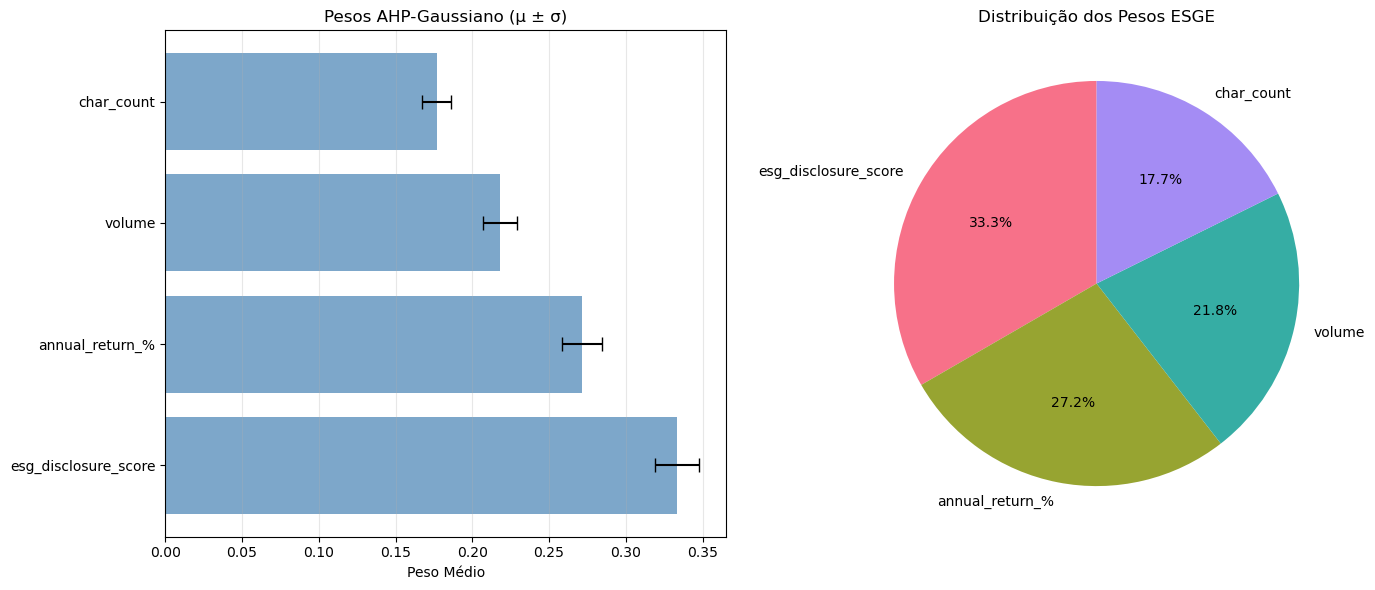

2026-04-21 00:35:14 | INFO | __main__ | 📊 Gráficos salvos


In [4]:
"""Visualização."""

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Bar chart com error bars
ax1.barh(
    weights_df['Criterion'],
    weights_df['Mean'],
    xerr=weights_df['Std'],
    capsize=5,
    color='steelblue',
    alpha=0.7
)
ax1.set_xlabel('Peso Médio')
ax1.set_title('Pesos AHP-Gaussiano (μ ± σ)')
ax1.grid(True, alpha=0.3, axis='x')

# 2. Pie chart
ax2.pie(
    weights_df['Mean'],
    labels=weights_df['Criterion'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('husl', len(weights_df))
)
ax2.set_title('Distribuição dos Pesos ESGE')

plt.tight_layout()
plt.savefig(
    config.OUTPUTS_FIGURES / "ahp_weights.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

logger.info("📊 Gráficos salvos")

## 4️⃣ Aplicação: Score ESGE 2024

In [5]:
"""Calcular score ESGE para 2024."""

# Carregar dataset
df = pd.read_csv(config.DATA_PROCESSED / "esge_master.csv")

# Última observação (2024)
latest = df[df['year'] == df['year'].max()].iloc[0]

# Normalizar valores (Min-Max)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df[config.ESGE_CRITERIA]),
    columns=config.ESGE_CRITERIA
)
latest_normalized = df_normalized.iloc[-1]

# Calcular score
score_2024 = ahp.calculate_score(latest_normalized, weights_df)

print("\n" + "="*70)
print(f"🎯 SCORE ESGE 2024: {score_2024:.4f}")
print("="*70)
print("\nDecomposição por Dimensão:")
for _, row in weights_df.iterrows():
    criterion = row['Criterion']
    weight = row['Mean']
    value = latest_normalized[criterion]
    contribution = weight * value
    print(
        f"{criterion:<25} | "
        f"Peso: {weight:.4f} × "
        f"Valor: {value:.4f} = "
        f"{contribution:.4f}"
    )
print("="*70)


🎯 SCORE ESGE 2024: 0.5446

Decomposição por Dimensão:
esg_disclosure_score      | Peso: 0.3334 × Valor: 1.0000 = 0.3334
annual_return_%           | Peso: 0.2716 × Valor: 0.1478 = 0.0402
volume                    | Peso: 0.2183 × Valor: 0.0000 = 0.0000
char_count                | Peso: 0.1767 × Valor: 0.9680 = 0.1710


## ✅ Checklist

- [ ] AHP-Gaussiano executado (10.000 iterações)
- [ ] Pesos derivados (μ ± σ)
- [ ] CR validado (< 0.10)
- [ ] Tabela exportada (ahp_weights.csv)
- [ ] Gráficos gerados
- [ ] Score ESGE calculado

---

## 📚 Referências

- Saaty, T. L. (1980). *The Analytic Hierarchy Process*. McGraw-Hill.
- Santos, L. F. O. M., Oishi, J., & Yoshizawa, M. (2023). Gaussian Analytic Hierarchy Process: A probabilistic approach for decision making under uncertainty. *Expert Systems with Applications*, 214, 119130.

---

**Última Atualização:** 2026-04-16  
**Versão:** 1.0  
**Licença:** MIT